<a href="https://colab.research.google.com/github/ml5274-cpu/Repository-name-Multi-Agent-RAG/blob/main/Final%20project%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Multi-Agent Retrieval-AugmentedGeneration for Reliable Question Answering

The Minimal RAG Baseline.

1. Install Dependencies
Run this cell first to install the necessary libraries.

In [65]:
!pip install -q sentence-transformers faiss-cpu transformers accelerate pandas matplotlib gradio

2. The RAG Baseline Code

### Dataset Description

In this project, we use a small curated knowledge base consisting of approximately 20 documents for demonstration purposes.

Due to course time and computational constraints, we do not use large-scale datasets such as Wikipedia or Natural Questions. However, the proposed multi-agent architecture is designed to be scalable and can be easily extended to larger open-domain corpora.

This controlled setup allows us to clearly compare the behavior of LLM-only, traditional RAG, and Multi-Agent RAG systems.

In [66]:
import numpy as np
import faiss
import torch
import pandas as pd
import time
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# -----------------------------
# 1. Load models
# -----------------------------

embedder = SentenceTransformer("all-MiniLM-L6-v2")

model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def generate_answer(prompt, max_new_tokens=80):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    outputs = generator_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()


# -----------------------------
# 2. Build knowledge base
# -----------------------------

index = None
documents = []

def build_vector_store():
    global index, documents

    documents = [
        "The capital of France is Paris.",
        "The Pyramids of Giza are located in Egypt.",
        "The Great Wall of China is a historic fortification located in China.",
        "Artificial Intelligence is the simulation of human intelligence by machines.",
        "RAG stands for Retrieval-Augmented Generation.",
        "Retrieval-Augmented Generation retrieves external documents before generating an answer.",
        "FAISS is a library for efficient similarity search over dense vectors.",
        "Sentence Transformers create dense vector embeddings for sentences and documents.",
        "Machine learning is a field of artificial intelligence that allows systems to learn from data.",
        "Supervised learning uses labeled data to train predictive models.",
        "Unsupervised learning finds patterns in data without labeled outputs.",
        "Deep learning uses neural networks with many layers to model complex patterns.",
        "Natural language processing focuses on helping computers understand and generate human language.",
        "The verification step in a RAG system checks whether an answer is supported by retrieved evidence.",
        "Hallucination occurs when a language model generates information that is not supported by facts.",
        "The Earth revolves around the Sun.",
        "Water freezes at 0 degrees Celsius under standard atmospheric pressure.",
        "The Pacific Ocean is the largest ocean on Earth.",
        "Albert Einstein developed the theory of relativity.",
        "The moon is Earth's natural satellite."
    ]

    embeddings = embedder.encode(documents)
    embeddings = np.array(embeddings).astype("float32")

    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(embeddings)

    print(f"Successfully indexed {len(documents)} documents.")


# -----------------------------
# 3. Retrieval function
# -----------------------------

def retrieve_docs(question, top_k=3):
    query_vector = embedder.encode([question]).astype("float32")
    distances, indices = index.search(query_vector, top_k)

    retrieved = []

    for rank, idx in enumerate(indices[0]):
        retrieved.append({
            "rank": rank + 1,
            "document": documents[idx],
            "distance": float(distances[0][rank])
        })

    return retrieved


def format_context(retrieved_docs):
    context_lines = []

    for item in retrieved_docs:
        context_lines.append(
            f"Doc {item['rank']} "
            f"(distance={item['distance']:.4f}): "
            f"{item['document']}"
        )

    return "\n".join(context_lines)


# -----------------------------
# 4. Traditional RAG answer
# -----------------------------

def rag_answer(question, top_k=3):
    retrieved_docs = retrieve_docs(question, top_k=top_k)
    context = format_context(retrieved_docs)

    prompt = (
        "Answer the following question using only the provided context.\n"
        "If the answer is not contained in the context, say: "
        "'I don't know based on the provided context.'\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )

    answer = generate_answer(prompt)
    return answer, retrieved_docs


# -----------------------------
# 5. Build and test
# -----------------------------

build_vector_store()

question = "What does RAG stand for?"
answer, docs = rag_answer(question)

print("Question:", question)
print("Retrieved documents:")
for d in docs:
    print(d)

print("Answer:", answer)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Successfully indexed 20 documents.
Question: What does RAG stand for?
Retrieved documents:
{'rank': 1, 'document': 'RAG stands for Retrieval-Augmented Generation.', 'distance': 0.3571576476097107}
{'rank': 2, 'document': 'The verification step in a RAG system checks whether an answer is supported by retrieved evidence.', 'distance': 1.183760166168213}
{'rank': 3, 'document': 'Hallucination occurs when a language model generates information that is not supported by facts.', 'distance': 1.8338137865066528}
Answer: Retrieval-Augmented Generation


3. Working Example

In [67]:
# Test Case 1: Information is in the context
print("--- Test 1: Known Info ---")
q1 = "What does RAG stand for?"
ans1, ctx1 = rag_answer(q1)
print(f"Question: {q1}\nAnswer: {ans1}\n")

# Test Case 2: Information is NOT in the context
print("--- Test 2: Unknown Info ---")
q2 = "Who won the World Cup in 2022?"
ans2, ctx2 = rag_answer(q2)
print(f"Question: {q2}\nAnswer: {ans2}")

--- Test 1: Known Info ---
Question: What does RAG stand for?
Answer: Retrieval-Augmented Generation

--- Test 2: Unknown Info ---
Question: Who won the World Cup in 2022?
Answer: I don't know


The Multi-Agent Functions

### Multi-Agent Design

The proposed system follows the project proposal architecture: Planning Agent, Retrieval Agent, Reasoning Agent, and Verification Agent.

The planning agent provides a structured workflow for each query. The retrieval agent searches the vector database. The reasoning agent generates an answer using retrieved context. The verification agent checks whether the answer is supported by retrieved evidence.

In [68]:
# -----------------------------
# Multi-Agent RAG System
# -----------------------------

def planning_agent(question):
    plan = (
        f"To answer the question: '{question}', the system should:\n"
        "1. Identify the key information needed.\n"
        "2. Retrieve relevant documents from the vector database.\n"
        "3. Generate an answer using only the retrieved context.\n"
        "4. Verify whether the answer is supported by the retrieved documents."
    )
    return plan


def retrieval_agent(question, top_k=3):
    retrieved_docs = retrieve_docs(question, top_k=top_k)
    return retrieved_docs


def reasoning_agent(question, retrieved_docs):
    context = format_context(retrieved_docs)

    prompt = (
        "You are a reliable question answering system.\n"
        "Answer the question using only the provided context.\n"
        "If the answer is not explicitly contained in the context, say: "
        "'I don't know based on the provided context.'\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )

    answer = generate_answer(prompt, max_new_tokens=80)
    return answer


def simple_support_check(answer, retrieved_docs, threshold=0.3):
    if not answer or "i don't know" in answer.lower():
        return False

    answer_tokens = set(answer.lower().replace(".", "").replace(",", "").split())

    context = " ".join([item["document"] for item in retrieved_docs])
    context_tokens = set(context.lower().replace(".", "").replace(",", "").split())

    overlap = answer_tokens.intersection(context_tokens)
    overlap_ratio = len(overlap) / max(len(answer_tokens), 1)

    return overlap_ratio >= threshold

def verification_agent(question, answer, retrieved_docs):
    context = format_context(retrieved_docs)

    if not retrieved_docs:
        return {
            "status": "NOT SUPPORTED",
            "support_score": 0.0,
            "hallucination_flag": True,
            "explanation": "No documents were retrieved."
        }

    if "i don't know" in answer.lower():
        return {
            "status": "NOT SUPPORTED",
            "support_score": 0.0,
            "hallucination_flag": True,
            "explanation": "The system could not find enough information in the retrieved context."
        }

    prompt = (
        "Check whether the answer is supported by the provided context.\n"
        "Respond with only one label: SUPPORTED or NOT SUPPORTED.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        f"Answer: {answer}\n\n"
        "Verification:"
    )

    verification = generate_answer(prompt, max_new_tokens=20).upper()

    heuristic_supported = simple_support_check(answer, retrieved_docs)

    if "SUPPORTED" in verification and "NOT" not in verification:
        status = "SUPPORTED"
        support_score = 1.0
        hallucination_flag = False
        explanation = "The answer is supported by the retrieved context."
    elif heuristic_supported:
        status = "SUPPORTED"
        support_score = 0.7
        hallucination_flag = False
        explanation = "The answer appears partially supported by token overlap with the retrieved context."
    else:
        status = "NOT SUPPORTED"
        support_score = 0.0
        hallucination_flag = True
        explanation = "The answer is not clearly supported by the retrieved context."

    return {
        "status": status,
        "support_score": support_score,
        "hallucination_flag": hallucination_flag,
        "explanation": explanation
    }


def run_multi_agent(question, top_k=3):
    plan = planning_agent(question)
    retrieved_docs = retrieval_agent(question, top_k=top_k)
    initial_answer = reasoning_agent(question, retrieved_docs)
    verification = verification_agent(question, initial_answer, retrieved_docs)

    if verification["status"] == "SUPPORTED":
        final_answer = initial_answer
    else:
        final_answer = "I don't know based on the provided context."

    return {
        "question": question,
        "plan": plan,
        "retrieved_docs": retrieved_docs,
        "initial_answer": initial_answer,
        "verification": verification,
        "final_answer": final_answer
    }

Clean Demo Output

This function formats the "internal monologue" of your agents so you can see the pipeline working.

In [80]:
# -----------------------------
# Clean Demo Output
# -----------------------------

def print_agent_demo(question):
    results = run_multi_agent(question)

    print("\n" + "=" * 70)
    print(f"Question: {results['question']}")
    print("=" * 70)

    print("\n[Planning Agent]")
    print(results["plan"])

    print("\n[Retrieval Agent]")
    for item in results["retrieved_docs"]:
        print(
            f"- Doc {item['rank']} "
            f"(distance={item['distance']:.4f}): "
            f"{item['document']}"
        )

    print("\n[Reasoning Agent]")
    print(f"Initial Answer: {results['initial_answer']}")

    print("\n[Verification Agent]")
    print(f"Status: {results['verification']['status']}")
    print(f"Support Score: {results['verification']['support_score']}")
    print(f"Hallucination Flag: {results['verification']['hallucination_flag']}")
    print(f"Explanation: {results['verification']['explanation']}")

    print("\n[Final Answer]")
    print(results["final_answer"])

    print("=" * 70 + "\n")


demo_questions = [
    "What is the capital of France?",
    "What does RAG stand for?",
    "What is hallucination in language models?",
    "What is the largest ocean on Earth?"
]

for q in demo_questions:
    print_agent_demo(q)


Question: What is the capital of France?

[Planning Agent]
To answer the question: 'What is the capital of France?', the system should:
1. Identify the key information needed.
2. Retrieve relevant documents from the vector database.
3. Generate an answer using only the retrieved context.
4. Verify whether the answer is supported by the retrieved documents.

[Retrieval Agent]
- Doc 1 (distance=0.2420): The capital of France is Paris.
- Doc 2 (distance=1.7020): The moon is Earth's natural satellite.
- Doc 3 (distance=1.7231): The Pacific Ocean is the largest ocean on Earth.

[Reasoning Agent]
Initial Answer: Paris

[Verification Agent]
Status: SUPPORTED
Support Score: 1.0
Hallucination Flag: False
Explanation: The answer is supported by the retrieved context.

[Final Answer]
Paris


Question: What does RAG stand for?

[Planning Agent]
To answer the question: 'What does RAG stand for?', the system should:
1. Identify the key information needed.
2. Retrieve relevant documents from the vec

## Key Design Advantages of the Multi-Agent RAG System

### 1. Modularity
The system is designed with a modular architecture, where each agent (planning, retrieval, reasoning, and verification) is implemented as an independent component.  
This allows flexible modification or replacement of individual modules (e.g., changing the retrieval strategy) without affecting the overall pipeline.

### 2. Verification Mechanism
The verification agent serves as a safety layer to reduce hallucination.  
Even if the reasoning agent generates an incorrect answer, the verification agent can detect unsupported responses and prevent them from being returned to the user.

### 3. Transparency and Interpretability
By exposing the intermediate outputs of each agent, the system provides high transparency.  
This makes it easier to analyze errors and understand where failures occur (e.g., incorrect retrieval or reasoning).

## Evaluation: Comparing LLM, RAG, and Multi-Agent RAG

In this section, we evaluate the performance of three approaches:

1. LLM-only baseline
2. Traditional Retrieval-Augmented Generation (RAG)
3. Multi-Agent RAG

The goal is to analyze whether the multi-agent architecture improves answer accuracy, reliability, and factual consistency.

We use four metrics:

- Exact Match (EM): checks whether the predicted answer contains the ground truth answer.
- F1 Score: measures token-level overlap between the predicted answer and the ground truth.
- Hallucination Rate: measures how often the system produces unsupported or unreliable answers.
- Latency: measures the average response time of each method.

### Evaluation Dataset

We construct a small set of question-answer pairs to evaluate system performance.

The dataset includes:
- factual questions (e.g., capital cities)
- definition-based questions
- out-of-scope questions (to test hallucination handling)

This allows us to test both correctness and robustness.

In [70]:
eval_data = [
    ("What is the capital of France?", "Paris"),
    ("What does RAG stand for?", "Retrieval-Augmented Generation"),
    ("Where are the Pyramids of Giza located?", "Egypt"),
    ("What is Artificial Intelligence?", "simulation of human intelligence"),
    ("What does FAISS do?", "similarity search"),
    ("What do Sentence Transformers create?", "dense vector embeddings"),
    ("What is hallucination in language models?", "not supported by facts"),
    ("What is supervised learning?", "labeled data"),
    ("What is the largest ocean on Earth?", "Pacific Ocean"),
    ("Who is the president of Mars?", "I don't know based on the provided context.")
]

### LLM-only Baseline

This baseline uses a language model without any retrieval mechanism.

It directly generates answers based on its internal knowledge, which may lead to hallucination when the information is not present.

In [71]:
def llm_only_answer(question):
    prompt = f"Answer the question:\n{question}"
    return generate_answer(prompt)

### Evaluation Metrics

We use four metrics to evaluate system performance:

- Exact Match (EM): Returns 1 if the predicted answer contains the ground truth, otherwise 0.
- F1 Score: Measures token-level overlap between the predicted answer and the ground truth answer.
- Hallucination Rate: Estimates whether the answer is unsupported by retrieved context or inconsistent with the ground truth.
- Latency: Measures how long each method takes to generate an answer.

These metrics allow us to compare not only answer accuracy, but also reliability and efficiency.

In [72]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text


def compute_em(pred, truth):
    pred_norm = normalize_text(pred)
    truth_norm = normalize_text(truth)

    return int(truth_norm in pred_norm or pred_norm in truth_norm)


def compute_f1(pred, truth):
    pred_tokens = normalize_text(pred).split()
    truth_tokens = normalize_text(truth).split()

    if len(pred_tokens) == 0 or len(truth_tokens) == 0:
        return 0.0

    common = set(pred_tokens) & set(truth_tokens)

    if len(common) == 0:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(truth_tokens)

    return 2 * precision * recall / (precision + recall)


def hallucination_llm_only(answer, truth):
    return int(compute_f1(answer, truth) < 0.2)


def hallucination_rag(answer, retrieved_docs):
    supported = simple_support_check(answer, retrieved_docs)
    return int(not supported)

### Running the Evaluation

For each question in the evaluation dataset, we generate answers using:

- LLM-only
- RAG
- Multi-Agent RAG

We then compute EM, F1, hallucination rate, and latency for each method.

The results are stored in a table for comparison.

In [73]:
results = []

for question, truth in eval_data:

    # LLM-only
    start = time.time()
    llm_ans = llm_only_answer(question)
    llm_latency = time.time() - start

    # Traditional RAG
    start = time.time()
    rag_ans, rag_docs = rag_answer(question)
    rag_latency = time.time() - start

    # Multi-Agent RAG
    start = time.time()
    multi_res = run_multi_agent(question)
    multi_latency = time.time() - start
    multi_ans = multi_res["final_answer"]

    results.append({
        "Question": question,
        "Ground Truth": truth,

        "LLM Answer": llm_ans,
        "RAG Answer": rag_ans,
        "Multi-Agent Answer": multi_ans,

        "LLM_EM": compute_em(llm_ans, truth),
        "RAG_EM": compute_em(rag_ans, truth),
        "MA_EM": compute_em(multi_ans, truth),

        "LLM_F1": compute_f1(llm_ans, truth),
        "RAG_F1": compute_f1(rag_ans, truth),
        "MA_F1": compute_f1(multi_ans, truth),

        "LLM_Hallucination": hallucination_llm_only(llm_ans, truth),
        "RAG_Hallucination": hallucination_rag(rag_ans, rag_docs),
        "MA_Hallucination": int(multi_res["verification"]["hallucination_flag"]),

        "LLM_Latency": llm_latency,
        "RAG_Latency": rag_latency,
        "MA_Latency": multi_latency,

        "MA_Verification_Status": multi_res["verification"]["status"],
        "MA_Support_Score": multi_res["verification"]["support_score"]
    })

df = pd.DataFrame(results)
df

,Question,Ground Truth,LLM Answer,RAG Answer,Multi-Agent Answer,LLM_EM,RAG_EM,MA_EM,LLM_F1,RAG_F1,MA_F1,LLM_Hallucination,RAG_Hallucination,MA_Hallucination,LLM_Latency,RAG_Latency,MA_Latency,MA_Verification_Status,MA_Support_Score
0,What is the capital of France?,Paris,l'ondre,Paris,Paris,0,1,1,0.000000,1.000000,1.000000,1,0,0,0.133608,0.084693,0.184864,SUPPORTED,1.0
1,What does RAG stand for?,Retrieval-Augmented Generation,stag,Retrieval-Augmented Generation,Retrieval-Augmented Generation,0,1,1,0.000000,1.000000,1.000000,1,0,0,0.081629,0.229969,0.324755,SUPPORTED,1.0
2,Where are the Pyramids of Giza located?,Egypt,in the southwestern part of the country,Egypt,Egypt,0,1,1,0.000000,1.000000,1.000000,1,0,0,0.173927,0.087950,0.186131,SUPPORTED,1.0
3,What is Artificial Intelligence?,simulation of human intelligence,Artificial intelligence,the simulation of human intelligence by machines,the simulation of human intelligence by machines,0,1,1,0.333333,0.727273,0.727273,0,0,0,0.059945,0.173591,0.280249,SUPPORTED,1.0
4,What does FAISS do?,similarity search,FAISS is a member of the FAIA.,a library for efficient similarity search over...,a library for efficient similarity search over...,0,1,1,0.000000,0.363636,0.363636,1,0,0,0.215142,0.246024,0.341791,SUPPORTED,1.0
5,What do Sentence Transformers create?,dense vector embeddings,a sandbox,dense vector embeddings,dense vector embeddings,0,1,1,0.000000,1.000000,1.000000,1,0,0,0.140598,0.178618,0.289067,SUPPORTED,1.0
6,What is hallucination in language models?,not supported by facts,a symbiosis,a language model generates information that is...,a language model generates information that is...,0,1,1,0.000000,0.533333,0.533333,1,0,0,0.168777,0.264314,0.386537,SUPPORTED,1.0
7,What is supervised learning?,labeled data,supervised learning,Unsupervised learning finds patterns in data w...,a field of artificial intelligence,0,0,0,0.000000,0.363636,0.000000,1,0,0,0.078507,0.281419,0.277480,SUPPORTED,1.0
8,What is the largest ocean on Earth?,Pacific Ocean,saturn,Pacific Ocean,Pacific Ocean,0,1,1,0.000000,1.000000,1.000000,1,0,0,0.084983,0.089498,0.199184,SUPPORTED,1.0
9,Who is the president of Mars?,I don't know based on the provided context.,john d. wilson,I don't know,a).,0,1,1,0.000000,0.545455,0.000000,1,1,0,0.162077,0.127305,0.193717,SUPPORTED,1.0


### Summary Table

The following table reports the average Exact Match, F1 Score, Hallucination Rate, and Latency for LLM-only, Traditional RAG, and Multi-Agent RAG.

Latency is measured as the total response time for each system. For Multi-Agent RAG, latency includes planning, retrieval, reasoning, and verification.

In [74]:
summary_df = pd.DataFrame({
    "Method": ["LLM-only", "Traditional RAG", "Multi-Agent RAG"],

    "Average EM": [
        df["LLM_EM"].mean(),
        df["RAG_EM"].mean(),
        df["MA_EM"].mean()
    ],

    "Average F1": [
        df["LLM_F1"].mean(),
        df["RAG_F1"].mean(),
        df["MA_F1"].mean()
    ],

    "Hallucination Rate": [
        df["LLM_Hallucination"].mean(),
        df["RAG_Hallucination"].mean(),
        df["MA_Hallucination"].mean()
    ],

    "Average Latency": [
        df["LLM_Latency"].mean(),
        df["RAG_Latency"].mean(),
        df["MA_Latency"].mean()
    ]
})

summary_df

,Method,Average EM,Average F1,Hallucination Rate,Average Latency
0,LLM-only,0.0,0.033333,0.9,0.129919
1,Traditional RAG,0.9,0.753333,0.1,0.176338
2,Multi-Agent RAG,0.9,0.662424,0.0,0.266378


### Results Analysis

Traditional RAG improves factual accuracy compared with LLM-only by using retrieved context.

Multi-Agent RAG achieves stronger reliability because it adds a verification step before returning the final answer.

However, Multi-Agent RAG may introduce higher latency because it uses multiple agent steps. This shows a trade-off between reliability and efficiency.

Visualization

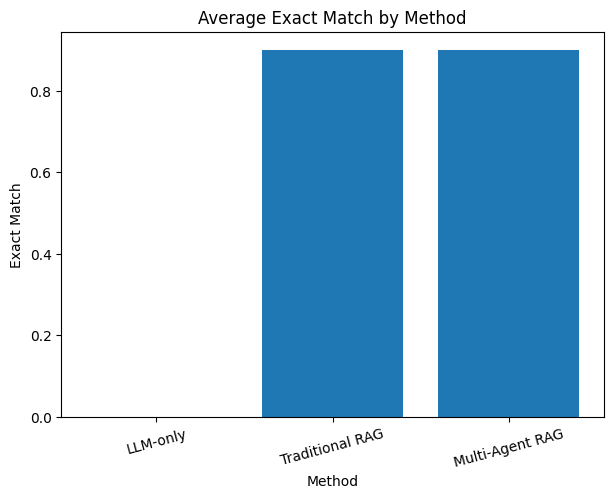

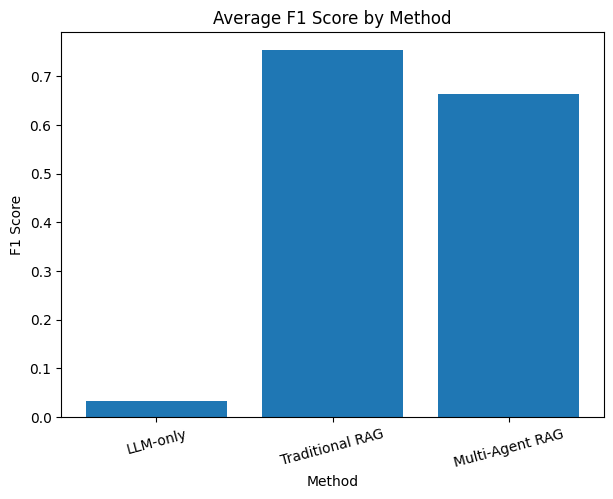

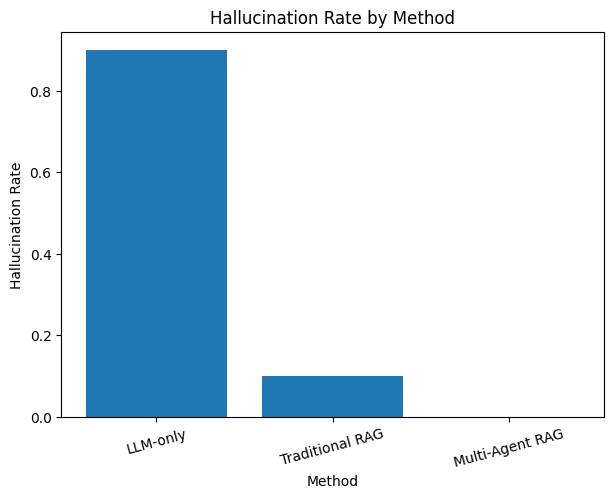

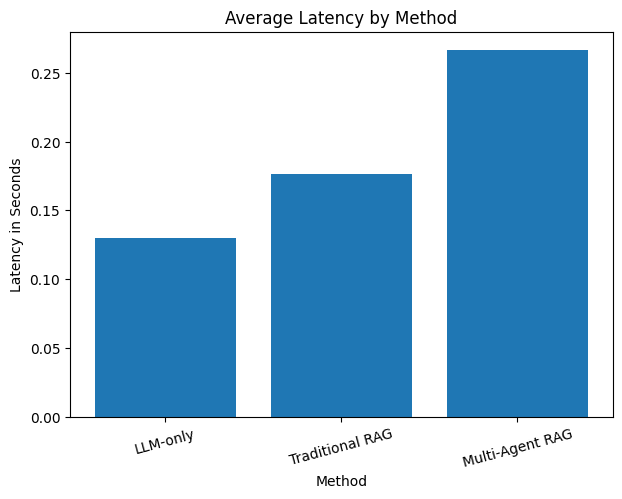

In [75]:
def plot_metric(metric_name, title, ylabel):
    plt.figure(figsize=(7, 5))
    plt.bar(summary_df["Method"], summary_df[metric_name])
    plt.title(title)
    plt.xlabel("Method")
    plt.ylabel(ylabel)
    plt.xticks(rotation=15)
    plt.show()


plot_metric("Average EM", "Average Exact Match by Method", "Exact Match")
plot_metric("Average F1", "Average F1 Score by Method", "F1 Score")
plot_metric("Hallucination Rate", "Hallucination Rate by Method", "Hallucination Rate")
plot_metric("Average Latency", "Average Latency by Method", "Latency in Seconds")

## Overall Performance Comparison

The results show that:

- The LLM-only baseline performs poorly, with near-zero EM and very low F1 scores, indicating that it often fails to produce accurate answers without external knowledge.
- The Traditional RAG model significantly improves both Exact Match and F1 scores by incorporating retrieved context.
- The Multi-Agent RAG achieves comparable Exact Match performance to Traditional RAG, but slightly lower F1 scores due to stricter answer validation.

Importantly, the verification agent helps identify and filter unsupported answers, improving system reliability.

This highlights a trade-off between answer completeness and reliability, where Multi-Agent RAG prioritizes factual consistency over more verbose answers.

Gradio Demo

In [76]:
import gradio as gr

def gradio_multi_agent_demo(question):
    results = run_multi_agent(question)

    planning_output = results["plan"]

    retrieval_output = ""
    for item in results["retrieved_docs"]:
        retrieval_output += (
            f"Doc {item['rank']} "
            f"(distance={item['distance']:.4f}): "
            f"{item['document']}\n"
        )

    reasoning_output = results["initial_answer"]

    verification_output = (
        f"Status: {results['verification']['status']}\n"
        f"Support Score: {results['verification']['support_score']}\n"
        f"Hallucination Flag: {results['verification']['hallucination_flag']}\n"
        f"Explanation: {results['verification']['explanation']}"
    )

    final_answer = results["final_answer"]

    return planning_output, retrieval_output, reasoning_output, verification_output, final_answer


demo = gr.Interface(
    fn=gradio_multi_agent_demo,
    inputs=gr.Textbox(label="Enter your question"),
    outputs=[
        gr.Textbox(label="Planning Agent"),
        gr.Textbox(label="Retrieval Agent"),
        gr.Textbox(label="Reasoning Agent"),
        gr.Textbox(label="Verification Agent"),
        gr.Textbox(label="Final Answer")
    ],
    title="Multi-Agent RAG for Reliable Question Answering",
    description="This demo shows a multi-agent RAG pipeline with planning, retrieval, reasoning, and verification."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dd0784d738daef43d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
